In [4]:
# notebook cell: DDR_analysis.ipynb (主要流程)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emcee
import os

import sys 
from utils import (
    evaluate_mB, ln_posterior, fit_gp_DL,
    bao_DV_to_DL, bao_DM_to_DL, compute_DL_SN, compute_eta_samples, eta_chi2
)

# ---------- 配置 ----------
np.random.seed(42)
os.makedirs('fig', exist_ok=True)

n_cp = 36
n_walkers = 72
n_mcmc_steps = 1000
n_samples_plot = 1000 

# ---------- 读取数据 ----------
c = 299792.458
z_bao_dv, DV_rd, DV_rd_err = np.loadtxt('data/Combine_DV_rd.dat', unpack=True)
z_bao_dm, DM_rd, DM_rd_err = np.loadtxt('data/Combine_DM_rd.dat', unpack=True)
_, H_dv, H_dv_err = np.loadtxt('output/Hz_DVreconstruct_results.txt', unpack=True)

sn_df = pd.read_csv('data/Pantheon+SH0ES.dat', sep=' ')
z_sn = sn_df['zHD'].values
m_obs = sn_df['m_b_corr'].values
m_obs_err = sn_df['m_b_corr_err_DIAG'].values

# 协方差
with open('data/Pantheon+SH0ES_STAT+SYS.cov', 'r') as f:
    lines = f.readlines()
N_cov = int(lines[0].strip())
cov_vec = np.array([float(x.strip()) for x in lines[1:]])
cov_full = cov_vec.reshape((N_cov, N_cov))
cov_inv = np.linalg.inv(cov_full)

# 控制点的对应红移
z_cp = np.logspace(np.log10(0.01), np.log10(max(z_sn)), n_cp)

# ---------- emcee 初始化 ----------
# 用控制点线性差值得到在z_cp处的m值作为初始值
m_cp_init = np.interp(z_cp, z_sn, m_obs)
initial_walkers = m_cp_init + 0.1 * np.random.randn(n_walkers, n_cp)

# 用 emcee 采样（保持原逻辑：ln_posterior 需要传入 z_cp）
sampler = emcee.EnsembleSampler(n_walkers, n_cp, ln_posterior, args=(z_sn, m_obs, cov_inv, z_cp))

print("Running emcee MCMC for mB(z)...")
sampler.run_mcmc(initial_walkers, n_mcmc_steps, progress=True)
mB_cp_chain = sampler.get_chain(discard=200, flat=True)
print("MCMC done. chain shape:", mB_cp_chain.shape)

Cov_mB_cp = np.cov(mB_cp_chain, rowvar=False)

Running emcee MCMC for mB(z)...


100%|██████████| 1000/1000 [00:47<00:00, 20.95it/s]

MCMC done. chain shape: (57600, 36)


In [5]:
mB_cp_mean = np.mean(mB_cp_chain, axis=0)
mB_cp_std = np.sqrt(np.diag(Cov_mB_cp))
np.savetxt("output/mB_cp_summary.txt", np.c_[z_cp, mB_cp_mean, mB_cp_std], header="z_cp  mB_mean  mB_std")
np.save("output/Cov_mB_cp.npy", Cov_mB_cp)
np.save("output/mB_cp_chain.npy", mB_cp_chain)
np.save("output/z_cp.npy", z_cp)


Processing prior: Planck2018+$M_B^\text{SH0ES}$


/workspaces/CDDR_Test/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:526: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  y_samples = rng.multivariate_normal(y_mean, y_cov, n_samples).T


chi2: 154.83, p-value: 0.0000
Number of BAO points: 11


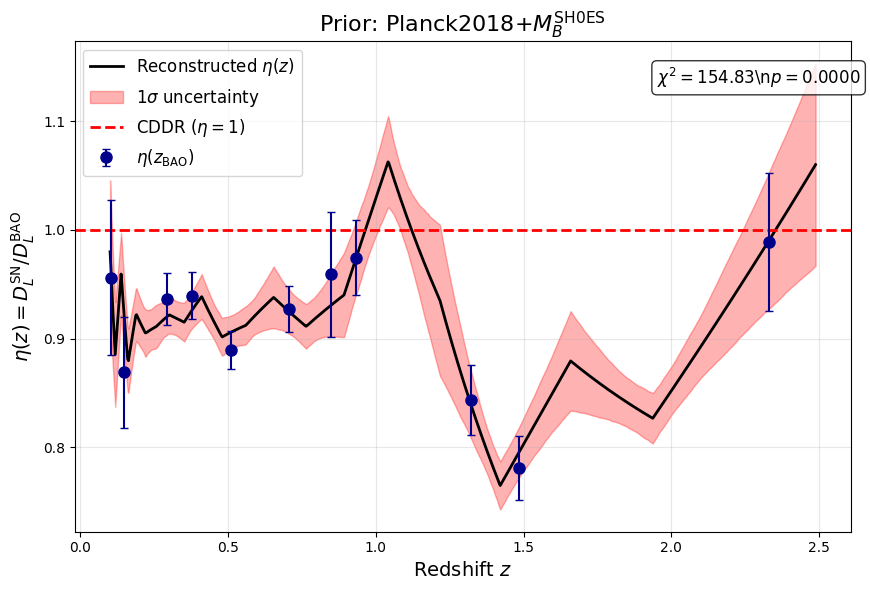

BAO information
BAO point 1: z=0.106, η=0.9560 ± 0.0714
BAO point 2: z=0.150, η=0.8690 ± 0.0513
BAO point 3: z=0.295, η=0.9366 ± 0.0237
BAO point 4: z=0.380, η=0.9396 ± 0.0217
BAO point 5: z=0.510, η=0.8894 ± 0.0173
BAO point 6: z=0.706, η=0.9273 ± 0.0212
BAO point 7: z=0.850, η=0.9591 ± 0.0572
BAO point 8: z=0.934, η=0.9746 ± 0.0343
BAO point 9: z=1.321, η=0.8436 ± 0.0319
BAO point 10: z=1.484, η=0.7813 ± 0.0294
BAO point 11: z=2.330, η=0.9888 ± 0.0637

Processing prior: Planck2018+$M_B^\text{B23}$


/workspaces/CDDR_Test/.venv/lib/python3.12/site-packages/sklearn/gaussian_process/_gpr.py:526: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  y_samples = rng.multivariate_normal(y_mean, y_cov, n_samples).T


chi2: 38.69, p-value: 0.0001
Number of BAO points: 11


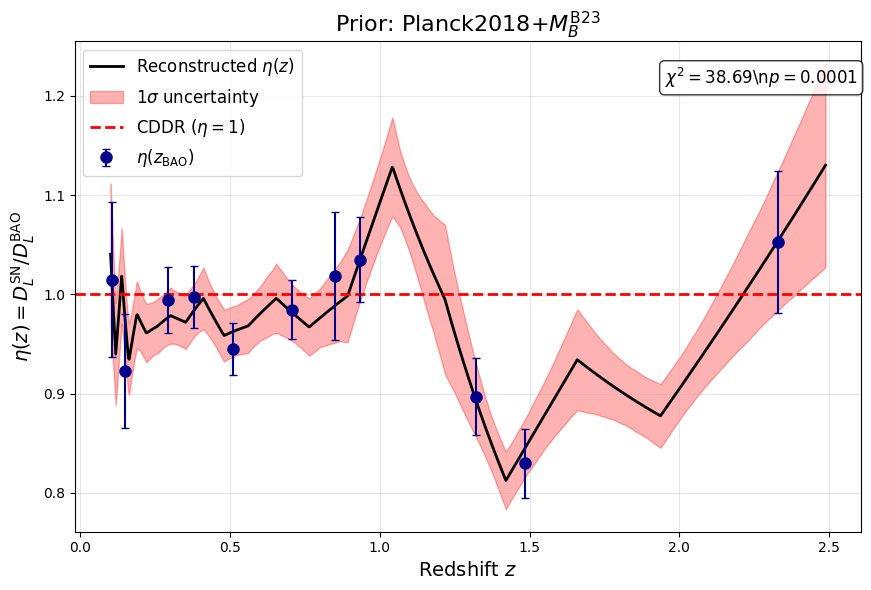

BAO information
BAO point 1: z=0.106, η=1.0149 ± 0.0785
BAO point 2: z=0.150, η=0.9227 ± 0.0576
BAO point 3: z=0.295, η=0.9942 ± 0.0330
BAO point 4: z=0.380, η=0.9974 ± 0.0310
BAO point 5: z=0.510, η=0.9450 ± 0.0266
BAO point 6: z=0.706, η=0.9843 ± 0.0298
BAO point 7: z=0.850, η=1.0183 ± 0.0645
BAO point 8: z=0.934, η=1.0348 ± 0.0427
BAO point 9: z=1.321, η=0.8968 ± 0.0387
BAO point 10: z=1.484, η=0.8298 ± 0.0348
BAO point 11: z=2.330, η=1.0527 ± 0.0711


In [6]:
priors = [
    {"name":"Planck2018MB0", "label":"Planck2018+$M_B^\\text{SH0ES}$", "MB": -19.253, "MB_err": 0.027, "rd": 147.09, "rd_err": 0.26},
    # {"name":"Planck2018MB23", "label":"Planck2018+$M_B^\\text{B23}$", "MB": -19.396, "MB_err": 0.0404, "rd": 147.09, "rd_err": 0.26},
    {"name":"Planck2018MB23", "label":"Planck2018+$M_B^\\text{B23}$", "MB": -19.384, "MB_err": 0.052, "rd": 147.09, "rd_err": 0.26},
]
z_eval = np.linspace(0.01, max(z_sn) * 1.1, 1000)
n_MC = 1000

# ---------- 主循环（对每个先验） ----------
for prior in priors:
    MB = prior["MB"]; MB_err = prior["MB_err"]
    rd = prior["rd"]; rd_err = prior["rd_err"]
    print(f"\nProcessing prior: {prior['label']}")

    # BAO: 把两种BAO数据转化为 DL
    DL_bao_DV, DL_bao_DV_err = bao_DV_to_DL(z_bao_dv, DV_rd, DV_rd_err, H_dv, H_dv_err, rd, rd_err)
    DL_bao_DM, DL_bao_DM_err = bao_DM_to_DL(z_bao_dm, DM_rd, DM_rd_err, rd, rd_err)

    # 合并 BAO 点（保存原始观测数据）
    z_bao_obs = np.concatenate((z_bao_dv, z_bao_dm))           # BAO观测红移
    DL_bao_obs = np.concatenate((DL_bao_DV, DL_bao_DM))        # BAO观测距离
    DL_bao_obs_err = np.concatenate((DL_bao_DV_err, DL_bao_DM_err)) # BAO观测误差

    # GP拟合BAO数据
    gp_bao = fit_gp_DL(z_bao_obs, DL_bao_obs, DL_bao_obs_err)
    DL_bao_gp_mean, DL_bao_gp_std = gp_bao.predict(z_eval.reshape(-1,1), return_std=True)

    # 从GP中抽取BAO距离样本
    DL_bao_samples = gp_bao.sample_y(z_eval.reshape(-4,1), n_MC).T

    # 超新星抽样
    n_MC = 1000
    chain_indices = np.random.choice(len(mB_cp_chain), n_MC, replace=False)
    MB_samples = np.random.normal(MB, MB_err, n_MC)

    # 计算SN距离（在整个红移网格上）
    DL_sn_samples = np.zeros((n_MC, len(z_eval)))
    for i, chain_idx in enumerate(chain_indices):
        DL_sn_samples[i] = compute_DL_SN(z_eval, mB_cp_chain[chain_idx], MB_samples[i], z_cp)
    
    DL_sn_mean = np.mean(DL_sn_samples, axis=0)
    DL_sn_err = 0.5 * (np.percentile(DL_sn_samples, 84, axis=0) - np.percentile(DL_sn_samples, 16, axis=0))

    # 计算SN距离（在BAO观测红移点上）→ 用于画BAO点的误差棒
    DL_sn_at_bao = np.zeros((n_MC, len(z_bao_obs)))
    for i, chain_idx in enumerate(chain_indices):
        DL_sn_at_bao[i] = compute_DL_SN(z_bao_obs, mB_cp_chain[chain_idx], MB_samples[i], z_cp)
    
    DL_sn_mean_at_bao = np.mean(DL_sn_at_bao, axis=0)   # 在BAO红移处的SN距离中值
    DL_sn_err_at_bao = 0.5 * (np.percentile(DL_sn_at_bao, 84, axis=0) - np.percentile(DL_sn_at_bao, 16, axis=0))
    
    # 计算η(z) = SN距离 / BAO距离
    eta_samples = DL_sn_samples / DL_bao_samples
    eta_mean = np.mean(eta_samples, axis=0)
    eta_err = 0.5 * (np.percentile(eta_samples, 84, axis=0) - np.percentile(eta_samples, 16, axis=0))

    # 计算BAO观测点处的η值（用于误差棒）
    eta_at_bao = DL_sn_mean_at_bao / DL_bao_obs
    eta_err_at_bao = np.abs(eta_at_bao) * np.sqrt(
        (DL_sn_err_at_bao / DL_sn_mean_at_bao)**2 + (DL_bao_obs_err / DL_bao_obs)**2
    )

    # 计算chi2
    chi2_val, p_val = eta_chi2(eta_at_bao, eta_err_at_bao)
    print(f"chi2: {chi2_val:.2f}, p-value: {p_val:.4f}")
    print(f"Number of BAO points: {len(z_bao_obs)}")

    # 绘图
    plt.figure(figsize=(9,6))
    mask_plot = z_eval > 0.1
    
    # 1. η(z)重建曲线
    plt.plot(z_eval[mask_plot], eta_mean[mask_plot], color='black', 
             label=r'Reconstructed $\eta(z)$', linewidth=2)
    plt.fill_between(z_eval[mask_plot], 
                     eta_mean[mask_plot] - eta_err[mask_plot], 
                     eta_mean[mask_plot] + eta_err[mask_plot], 
                     color='red', alpha=0.3, label=r'1$\sigma$ uncertainty')
    
    # 2. η=1参考线
    plt.axhline(1.0, color='red', linestyle='--', linewidth=2, label=r'CDDR ($\eta=1$)')
    
    # 3. BAO观测点（这才是你要画的点！）
    plt.errorbar(z_bao_obs, eta_at_bao, yerr=eta_err_at_bao, 
                 fmt='o', color='darkblue', capsize=3, markersize=8, 
                 label=r'$\eta(z_{\mathrm{BAO}})$', zorder=5)
    
    # 4. 坐标轴和标题
    plt.xlabel('Redshift $z$', fontsize=14)
    plt.ylabel(r'$\eta(z) = D_L^{\mathrm{SN}} / D_L^{\mathrm{BAO}}$', fontsize=14)
    plt.title(f"Prior: {prior['label']}", fontsize=16)
    
    # 5. 统计信息
    textstr = rf'$\chi^2 = {chi2_val:.2f}$\n$p = {p_val:.4f}$'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.75, 0.95, textstr, transform=plt.gca().transAxes, 
             fontsize=12, verticalalignment='top', bbox=props)
    
    plt.legend(fontsize=12, loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(rf"fig/eta_reconstruct_{prior['name']}.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    
    # 打印BAO点信息
    print("BAO information")
    for i, (z, eta, eta_err) in enumerate(zip(z_bao_obs, eta_at_bao, eta_err_at_bao)):
        print(rf"BAO point {i+1}: z={z:.3f}, η={eta:.4f} ± {eta_err:.4f}")